In [7]:

# ==========================================================
# CELL 1 : INSTALL / IMPORTS / SETTINGS
# Run once
# ==========================================================

# pip install pandas numpy pillow tqdm requests torch transformers scikit-learn matplotlib

import os
import io
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

import torch
from transformers import CLIPProcessor, CLIPModel

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# ---------------- SETTINGS ----------------

CSV_PATH = "meta.csv"

URL_COL = "url"
YEAR_COL = "GT"

SAMPLE_PER_YEAR = 250

IMAGE_FOLDER = "downloaded_images"

BATCH_SIZE = 32
NUM_THREADS = 16
PCA_COMPONENTS = 90

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(IMAGE_FOLDER, exist_ok=True)

print("Using:", DEVICE)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/Users/mukund/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Using: cpu


In [6]:
import sys
!{sys.executable} -m pip install transformers

     |████████████████████████████████| 10.0 MB 4.0 MB/s eta 0:00:01
     |████████████████████████████████| 436 kB 21.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.7 MB 22.9 MB/s eta 0:00:01
     |████████████████████████████████| 566 kB 1.1 MB/s eta 0:00:01
     |████████████████████████████████| 193 kB 19.7 MB/s eta 0:00:01
     |████████████████████████████████| 3.8 MB 36.1 MB/s eta 0:00:01
  Attempting uninstall: fsspec
    Found existing installation: fsspec 0.9.0
    Uninstalling fsspec-0.9.0:
      Successfully uninstalled fsspec-0.9.0


In [8]:

# ==========================================================
# CELL 2 : LOAD CSV + SAMPLE DATA
# Run once
# ==========================================================

df = pd.read_csv(CSV_PATH)

df = df.dropna(subset=[URL_COL, YEAR_COL])

df[YEAR_COL] = df[YEAR_COL].astype(int)

df = df.groupby(YEAR_COL).head(SAMPLE_PER_YEAR).reset_index(drop=True)

print("Rows selected:", len(df))
df.head()

Rows selected: 17500


,img_id,GT,date_taken,date_granularity,url,username,title,license,license_url
0,16058756969,1957,1957-01-01 00:00:00,6,https://farm8.staticflickr.com/7563/1605875696...,Gertrud K.,1957,All Rights Reserved,NaN
1,8418118218,1957,1957-01-01 00:00:00,6,https://farm9.staticflickr.com/8189/8418118218...,h willome,Ubahebe Crater,All Rights Reserved,NaN
2,4644893892,1957,1957-01-01 00:00:00,6,https://farm4.staticflickr.com/3331/4644893892...,karin brigitta,1957,All Rights Reserved,NaN
3,148796311,1957,1957-01-01 00:00:00,6,https://farm1.staticflickr.com/29/148796311_4e...,nigel@hornchurch,"Philippines, 1957",All Rights Reserved,NaN
4,8418136138,1957,1957-01-01 00:00:00,6,https://farm9.staticflickr.com/8355/8418136138...,h willome,Bad water,All Rights Reserved,NaN


In [9]:
# ==========================================================
# CELL 2 : LOAD DATA + SAMPLE
# ==========================================================

df = pd.read_csv(CSV_PATH)

print("Columns:")
print(df.columns.tolist())

# remove missing rows
df = df.dropna(subset=[URL_COL, YEAR_COL])

# ensure integer year
df[YEAR_COL] = df[YEAR_COL].astype(int)

# sample 100 per year
df = df.groupby(YEAR_COL).head(SAMPLE_PER_YEAR).reset_index(drop=True)

print("Rows selected:", len(df))
print(df.head())

Columns:
['img_id', 'GT', 'date_taken', 'date_granularity', 'url', 'username', 'title', 'license', 'license_url']
Rows selected: 17500
        img_id    GT           date_taken  date_granularity  \
0  16058756969  1957  1957-01-01 00:00:00                 6   
1   8418118218  1957  1957-01-01 00:00:00                 6   
2   4644893892  1957  1957-01-01 00:00:00                 6   
3    148796311  1957  1957-01-01 00:00:00                 6   
4   8418136138  1957  1957-01-01 00:00:00                 6   

                                                 url          username  \
0  https://farm8.staticflickr.com/7563/1605875696...        Gertrud K.   
1  https://farm9.staticflickr.com/8189/8418118218...         h willome   
2  https://farm4.staticflickr.com/3331/4644893892...    karin brigitta   
3  https://farm1.staticflickr.com/29/148796311_4e...  nigel@hornchurch   
4  https://farm9.staticflickr.com/8355/8418136138...         h willome   

               title              license

In [10]:

# ==========================================================
# CELL 3 : FAST PARALLEL IMAGE DOWNLOAD
# Run once only
# ==========================================================

def download_one(row):
    
    idx = row.name
    url = row[URL_COL]
    
    save_path = os.path.join(IMAGE_FOLDER, f"{idx}.jpg")
    
    if os.path.exists(save_path):
        return save_path
    
    try:
        r = requests.get(url, timeout=10)
        img = Image.open(io.BytesIO(r.content)).convert("RGB")
        img.save(save_path, quality=90)
        return save_path
    except:
        return None

rows = [row for _, row in df.iterrows()]

saved_paths = []

with ThreadPoolExecutor(max_workers=NUM_THREADS) as ex:
    
    for result in tqdm(ex.map(download_one, rows), total=len(rows)):
        saved_paths.append(result)

df["local_path"] = saved_paths

df = df.dropna(subset=["local_path"]).reset_index(drop=True)

print("Downloaded images:", len(df))

df.to_csv("sample_ready.csv", index=False)

100%|██████████| 17500/17500 [09:11<00:00, 31.76it/s] 

Downloaded images: 14611


In [11]:

# ==========================================================
# CELL 4 : LOAD CLIP MODEL
# Run once
# ==========================================================

model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(model_name).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(model_name)

clip_model.eval()

print("CLIP Loaded")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP Loaded


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [12]:

# ==========================================================
# CELL 5 : EXTRACT CLIP EMBEDDINGS
# Re-run this only if changing embedding logic
# ==========================================================

df = pd.read_csv("sample_ready.csv")
paths = df["local_path"].tolist()
years = df[YEAR_COL].tolist()

embeddings = []
targets = []

for i in tqdm(range(0, len(paths), BATCH_SIZE)):
    
    batch_paths = paths[i:i+BATCH_SIZE]
    batch_years = years[i:i+BATCH_SIZE]
    
    imgs = []
    yrs = []
    
    for p, y in zip(batch_paths, batch_years):
        try:
            img = Image.open(p).convert("RGB")
            imgs.append(img)
            yrs.append(y)
        except:
            pass
    
    if len(imgs) == 0:
        continue
    
    inputs = clip_processor(
        images=imgs,
        return_tensors="pt",
        padding=True
    ).to(DEVICE)

    with torch.no_grad():
        feats = clip_model.get_image_features(**inputs)

    if not isinstance(feats, torch.Tensor):
        feats = feats.pooler_output

    # L2-normalise — this is critical, CLIP is cosine-similarity based
    feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
    feats = feats.cpu().numpy()

    embeddings.extend(feats)
    targets.extend(yrs)

X = np.array(embeddings)
y = np.array(targets)

print("Embeddings:", X.shape)

np.save("X_clip.npy", X)
np.save("y_years.npy", y)

100%|██████████| 457/457 [48:55<00:00,  6.42s/it]

Embeddings: (14611, 512)


In [33]:
df = pd.read_csv("sample_ready.csv")


In [39]:
def extract_numeric_features(path):
    try:
        img = Image.open(path).convert("RGB")
        arr = np.array(img)

        h, w, c = arr.shape

        # -------- BASIC --------
        mean = arr.mean()
        std = arr.std()
        minv = arr.min()
        maxv = arr.max()

        # -------- CHANNEL MEANS --------
        r_mean = arr[:,:,0].mean()
        g_mean = arr[:,:,1].mean()
        b_mean = arr[:,:,2].mean()

        # -------- CHANNEL STDS --------
        r_std = arr[:,:,0].std()
        g_std = arr[:,:,1].std()
        b_std = arr[:,:,2].std()

        # -------- BRIGHTNESS / CONTRAST --------
        brightness = 0.299*r_mean + 0.587*g_mean + 0.114*b_mean
        contrast = std

        # -------- SHAPE --------
        aspect = w / h
        area = h * w

        # -------- EDGE FEATURES --------
        gx = np.abs(np.diff(arr, axis=1)).mean()
        gy = np.abs(np.diff(arr, axis=0)).mean()
        edge_strength = gx + gy

        # -------- COLOR RELATIONS --------
        rg_diff = abs(r_mean - g_mean)
        rb_diff = abs(r_mean - b_mean)
        gb_diff = abs(g_mean - b_mean)

        # -------- HISTOGRAM FEATURES --------
        hist_r = np.histogram(arr[:,:,0], bins=8, range=(0,255))[0]
        hist_g = np.histogram(arr[:,:,1], bins=8, range=(0,255))[0]
        hist_b = np.histogram(arr[:,:,2], bins=8, range=(0,255))[0]

        hist_features = np.concatenate([hist_r, hist_g, hist_b]) / (h*w)

        # -------- TEXTURE (variance of gradients) --------
        texture = np.var(np.diff(arr.astype(float), axis=0)) + np.var(np.diff(arr.astype(float), axis=1))

        return np.concatenate([
            [
                mean, std, minv, maxv,
                r_mean, g_mean, b_mean,
                r_std, g_std, b_std,
                brightness, contrast,
                aspect, area,
                gx, gy, edge_strength,
                rg_diff, rb_diff, gb_diff,
                texture
            ],
            hist_features  # adds 24 more → total ~45 features
        ])

    except:
        return np.zeros(45)

In [40]:
num_feats = []

for p in tqdm(df["local_path"]):
    num_feats.append(extract_numeric_features(p))

num_feats = np.array(num_feats)

print(num_feats.shape)  # ~ (N, 45)

100%|██████████| 14611/14611 [02:05<00:00, 116.47it/s]


(14611, 45)


In [41]:
from sklearn.preprocessing import StandardScaler
num_feats = StandardScaler().fit_transform(num_feats)
X = np.load("X_clip.npy")
y = np.load("y_years.npy")

In [42]:
X_combined = np.hstack([X, num_feats])
print(X_combined.shape)

(14611, 557)


In [43]:

    # ==========================================================
    # CELL 6 : TEST MULTIPLE CLASSIFIERS
    # Replace old Cell 6 fully
    # ==========================================================

    from sklearn.model_selection import train_test_split
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    from sklearn.pipeline import make_pipeline

    from sklearn.linear_model import LogisticRegression, SGDClassifier
    from sklearn.svm import LinearSVC

    from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

    import numpy as np

    # ==========================================================
    # PCA
    # ==========================================================

    pca = PCA(n_components=300)   # try 64 / 128 / 256 later
    X2 = pca.fit_transform(X_combined)

    # ==========================================================
    # Convert year -> 5-year bins
    # ==========================================================

    START_YEAR = 1930
    y_bins = ((y - START_YEAR) // 5).astype(int)

    # ==========================================================
    # Train test split
    # ==========================================================

    X_train, X_test, y_train, y_test, year_train, year_test = train_test_split(
        X2, y_bins, y,
        test_size=0.2,
        random_state=42,
        stratify=y_bins
    )

    # ==========================================================
    # MODELS
    # ==========================================================

    models = {

        "Logistic Regression":
            make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=3000)
            ),
        '''
        "Linear SVM":
            make_pipeline(
                StandardScaler(),
                LinearSVC(C=1.0, max_iter=5000)
            ),

        '''
        "SGD Classifier":
            make_pipeline(
                StandardScaler(),
                SGDClassifier(loss="hinge", max_iter=3000)
            ),

        "Random Forest":
            RandomForestClassifier(
                n_estimators=250,
                n_jobs=-1,
                random_state=42
            ),

        "Extra Trees":
            ExtraTreesClassifier(
                n_estimators=250,
                n_jobs=-1,
                random_state=42
            )
    }

    results = {}

    # ==========================================================
    # TRAIN LOOP
    # ==========================================================

    for name, model in models.items():

        print("\nTraining:", name)

        model.fit(X_train, y_train)

        pred_bins = model.predict(X_test)

        # convert predicted bin to center year
        pred_year = START_YEAR + pred_bins * 5 + 2

        mae = np.mean(np.abs(pred_year - year_test))

        acc5 = np.mean(np.abs(pred_year - year_test) <= 5) * 100

        cls_acc = np.mean(pred_bins == y_test) * 100

        results[name] = {
            "pred_year": pred_year,
            "true_year": year_test,
            "mae": mae,
            "acc5": acc5,
            "cls_acc": cls_acc
        }

        print("5-Year Bin Accuracy:", round(cls_acc,2), "%")
        print("MAE:", round(mae,2))
        print("±5 Year Accuracy:", round(acc5,2), "%")


Training: Logistic Regression
5-Year Bin Accuracy: 44.06 %
MAE: 7.03
±5 Year Accuracy: 60.01 %

Training: 
    "Linear SVM":
        make_pipeline(
            StandardScaler(),
            LinearSVC(C=1.0, max_iter=5000)
        ),
        
    SGD Classifier
5-Year Bin Accuracy: 36.44 %
MAE: 9.01
±5 Year Accuracy: 52.45 %

Training: Random Forest
5-Year Bin Accuracy: 43.35 %
MAE: 8.44
±5 Year Accuracy: 58.06 %

Training: Extra Trees
5-Year Bin Accuracy: 44.85 %
MAE: 8.12
±5 Year Accuracy: 58.26 %


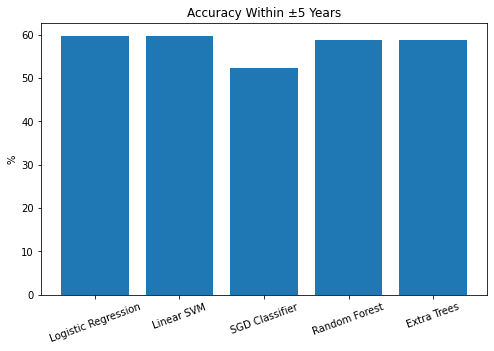

NameError: name 'preds' is not defined

<Figure size 504x504 with 0 Axes>

In [14]:
# ==========================================================
# CELL 7 : PLOTS
# Re-run anytime
# ==========================================================

best = max(results, key=lambda x: results[x]["acc5"])
# -------- Bar graph --------
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [results[k]["acc5"] for k in results])
plt.title("Accuracy Within ±5 Years")
plt.ylabel("%")
plt.xticks(rotation=20)
plt.show()

# -------- Scatter --------
plt.figure(figsize=(7,7))
plt.scatter(y_test, preds, alpha=0.6)

mn = min(y_test.min(), preds.min())
mx = max(y_test.max(), preds.max())

plt.plot([mn,mx],[mn,mx],'r--')

plt.xlabel("True Year")
plt.ylabel("Predicted Year")
plt.title(best)
plt.show()

# -------- Error Histogram --------
errors = preds - y_test

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)
plt.title("Prediction Errors")
plt.xlabel("Predicted - True")
plt.show()

print("BEST MODEL:", best)
print("MAE:", round(results[best]["mae"],2))
print("±5 Accuracy:", round(results[best]["acc5"],2), "%")
results[name] = {
        "preds": preds,
        "mae": mae,
        "acc5": acc5
    }

In [16]:
import sys

!{sys.executable} -m pip install torchvision

     |████████████████████████████████| 1.7 MB 2.8 MB/s eta 0:00:01


In [24]:
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(DEVICE)

mps


In [26]:
resnet = resnet.to(DEVICE)